In [1]:
!git clone https://github.com/SAJLENDRAPANDEY/flyrank-ml-internship-starter.git

Cloning into 'flyrank-ml-internship-starter'...
remote: Enumerating objects: 217, done.
remote: Counting objects: 100% (131/131), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 217 (delta 96), reused 64 (delta 64), pack-reused 86 (from 1)
Receiving objects: 100% (217/217), 1.88 MiB | 4.71 MiB/s, done.
Resolving deltas: 100% (102/102), done.


In [2]:
import os

os.chdir("/content/flyrank-ml-internship-starter")

print(os.getcwd())

/content/flyrank-ml-internship-starter


In [3]:
import os

dataset_path = "data/raw/content_refresh_anonymized.csv"

print(os.path.exists(dataset_path))

True


In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv(dataset_path)

In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 30000
Columns: 44


In [7]:
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [8]:
print(df.columns.tolist())

['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   object 
 11  model_used              24267 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null

In [10]:
df.describe()

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,sessions_prev_30d,content_age_days,age_tier_order,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct
count,27532.000000,27532.000000,27532.000000,22301.000000,22301.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,29875.000000,30000.000000,26612.000000
mean,158.882391,0.146954,0.485342,3107.760325,20665.277835,5200.366300,16.097333,49.942467,37.066633,35.937700,...,10.283000,256.16780,4.786533,46.098300,0.510733,16.34238,2.534520,18.212921,0.768196,-4.785969
std,1518.270825,0.285241,2.101560,1452.382598,10115.344042,16838.019547,75.076958,152.101430,107.069131,103.748185,...,42.578003,132.70793,0.790392,42.078709,3.279162,15.21679,8.310096,29.472768,7.429454,473.861780
min,0.000000,0.000000,0.000000,8.000000,40.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,90.00000,3.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-100.000000
25%,0.000000,0.000000,0.000000,2413.000000,15644.000000,81.000000,0.000000,2.000000,2.000000,2.000000,...,1.000000,132.00000,4.000000,20.000000,0.000000,6.20000,0.000000,0.000000,0.000000,-62.600000
50%,10.000000,0.000000,0.000000,2877.000000,19116.000000,731.000000,1.000000,8.000000,7.000000,7.000000,...,2.000000,236.00000,5.000000,20.000000,0.070000,10.80000,0.000000,5.000000,0.000000,-33.500000
75%,20.000000,0.130000,0.000000,3666.000000,24011.000000,3615.250000,7.000000,33.000000,27.000000,27.000000,...,7.000000,333.00000,5.000000,104.000000,0.290000,22.30000,1.350000,23.530000,0.000000,0.000000
max,74000.000000,1.000000,100.360000,9546.000000,111158.000000,517715.000000,4178.000000,5998.000000,4345.000000,4913.000000,...,4247.000000,564.00000,6.000000,373.000000,100.000000,245.00000,100.000000,300.000000,300.000000,44900.000000


In [11]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

,0
provider_used,21438
word_count,7699
char_count,7699
word_count_tier,7699
char_count_tier,7699
model_used,5733
trend_pct,3388
competition_level,2610
search_volume,2468
cpc,2468


In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [13]:
print("Total rows:", len(df))
print("Unique content IDs:", df["content_id"].nunique())

Total rows: 30000
Unique content IDs: 30000


In [14]:
print("Unique clients:", df["client_id"].nunique())

Unique clients: 32


In [15]:
df[
    [
        "days_since_last_update",
        "impressions_90d",
        "ctr",
        "avg_position",
        "pageviews_90d",
        "sessions_90d",
        "engagement_rate"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
days_since_last_update,30000.0,46.098300,42.078709,1.0,20.0,20.00,104.00,373.0
impressions_90d,30000.0,5200.366300,16838.019547,1.0,81.0,731.00,3615.25,517715.0
ctr,30000.0,0.510733,3.279162,0.0,0.0,0.07,0.29,100.0
avg_position,30000.0,16.342380,15.216790,0.0,6.2,10.80,22.30,245.0
pageviews_90d,30000.0,49.942467,152.101430,0.0,2.0,8.00,33.00,5998.0
sessions_90d,30000.0,37.066633,107.069131,1.0,2.0,7.00,27.00,4345.0
engagement_rate,30000.0,2.534520,8.310096,0.0,0.0,0.00,1.35,100.0


In [16]:
print(
    "Rows with avg_position = 0:",
    (df["avg_position"] == 0).sum()
)

Rows with avg_position = 0: 1205


In [17]:
df["ctr"].describe()

,ctr
count,30000.000000
mean,0.510733
std,3.279162
min,0.000000
25%,0.000000
50%,0.070000
75%,0.290000
max,100.000000


In [18]:
print("CTR median:", df["ctr"].median())

CTR median: 0.07


In [19]:
df["impressions_90d"].describe()

,impressions_90d
count,30000.000000
mean,5200.366300
std,16838.019547
min,1.000000
25%,81.000000
50%,731.000000
75%,3615.250000
max,517715.000000


In [20]:
print(
    "Impressions median:",
    df["impressions_90d"].median()
)

Impressions median: 731.0


In [21]:
df["days_since_last_update"].describe()

,days_since_last_update
count,30000.000000
mean,46.098300
std,42.078709
min,1.000000
25%,20.000000
50%,20.000000
75%,104.000000
max,373.000000


In [22]:
print(
    "Median days since update:",
    df["days_since_last_update"].median()
)

Median days since update: 20.0


EDA


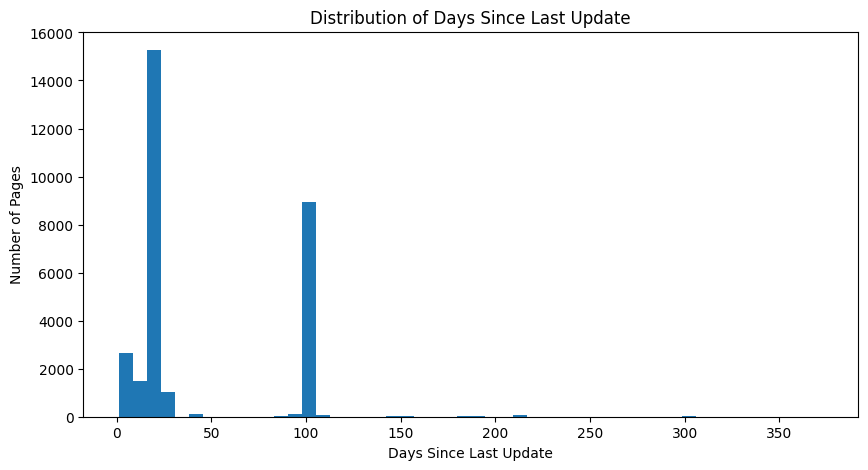

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    df["days_since_last_update"],
    bins=50
)

plt.xlabel("Days Since Last Update")
plt.ylabel("Number of Pages")
plt.title("Distribution of Days Since Last Update")

plt.show()

In [24]:
df["update_age_bucket"] = pd.cut(
    df["days_since_last_update"],
    bins=[-1, 30, 90, 180, 365, float("inf")],
    labels=[
        "0-30",
        "31-90",
        "91-180",
        "181-365",
        "365+"
    ]
)

age_summary = (
    df["update_age_bucket"]
    .value_counts()
    .sort_index()
)

print(age_summary)

update_age_bucket
0-30       20480
31-90        175
91-180      9171
181-365      169
365+           5
Name: count, dtype: int64


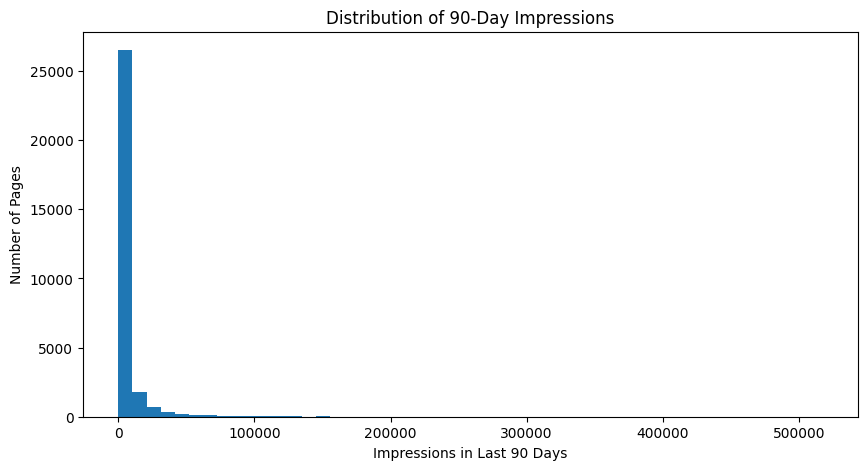

In [25]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["impressions_90d"],
    bins=50
)

plt.xlabel("Impressions in Last 90 Days")
plt.ylabel("Number of Pages")
plt.title("Distribution of 90-Day Impressions")

plt.show()

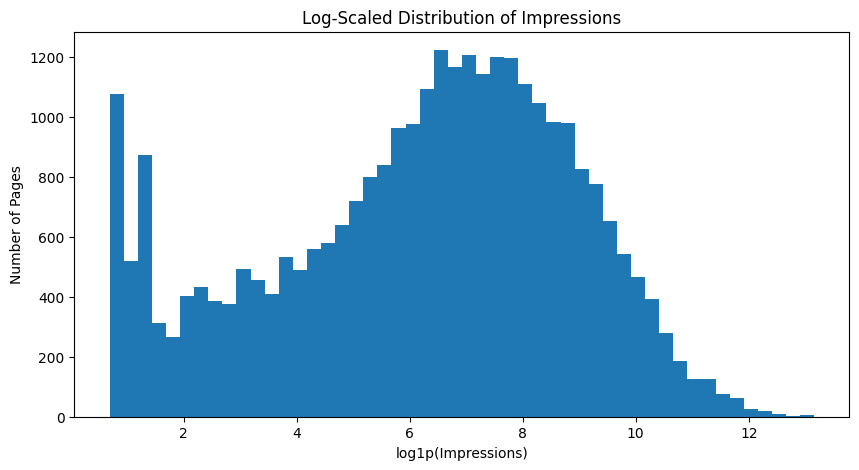

In [26]:
plt.figure(figsize=(10, 5))

plt.hist(
    np.log1p(df["impressions_90d"]),
    bins=50
)

plt.xlabel("log1p(Impressions)")
plt.ylabel("Number of Pages")
plt.title("Log-Scaled Distribution of Impressions")

plt.show()

In [27]:
df["impression_bucket"] = pd.cut(
    df["impressions_90d"],
    bins=[-1, 100, 500, 1000, 3000, 10000, float("inf")],
    labels=[
        "0-100",
        "101-500",
        "501-1000",
        "1001-3000",
        "3001-10000",
        "10000+"
    ]
)

print(
    df["impression_bucket"]
    .value_counts()
    .sort_index()
)

impression_bucket
0-100         8006
101-500       5279
501-1000      3206
1001-3000     5226
3001-10000    4681
10000+        3602
Name: count, dtype: int64


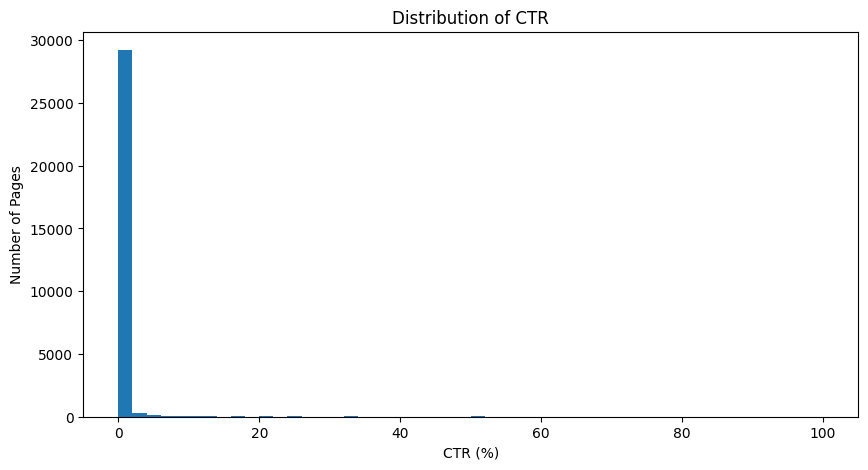

In [28]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["ctr"],
    bins=50
)

plt.xlabel("CTR (%)")
plt.ylabel("Number of Pages")
plt.title("Distribution of CTR")

plt.show()

In [29]:
df["ctr_bucket"] = pd.cut(
    df["ctr"],
    bins=[-float("inf"), 0.05, 0.1, 0.5, 1, 2, float("inf")],
    labels=[
        "<0.05%",
        "0.05-0.1%",
        "0.1-0.5%",
        "0.5-1%",
        "1-2%",
        "2%+"
    ]
)

print(
    df["ctr_bucket"]
    .value_counts()
    .sort_index()
)

ctr_bucket
<0.05%       14419
0.05-0.1%     2077
0.1-0.5%      9355
0.5-1%        2460
1-2%           915
2%+            774
Name: count, dtype: int64


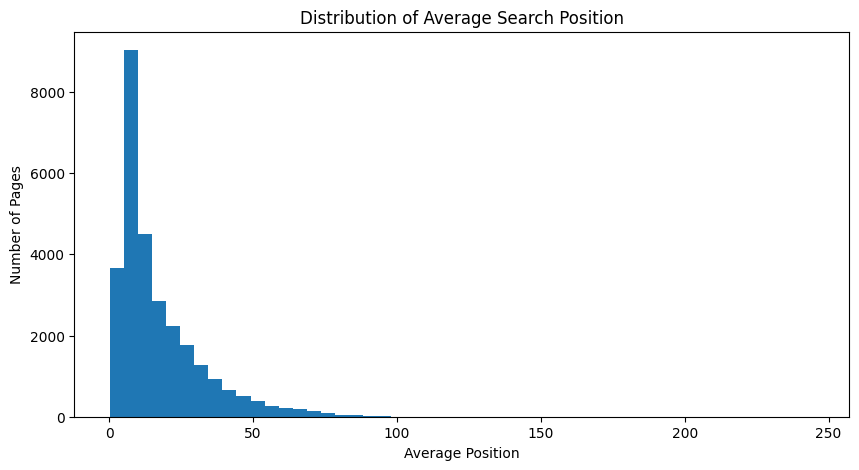

In [30]:
plt.figure(figsize=(10, 5))

position_data = df.loc[
    df["avg_position"] > 0,
    "avg_position"
]

plt.hist(
    position_data,
    bins=50
)

plt.xlabel("Average Position")
plt.ylabel("Number of Pages")
plt.title("Distribution of Average Search Position")

plt.show()

In [33]:
old_pages = df[
    df["days_since_last_update"] >= 90
]

print("Pages >= 90 days old:", len(old_pages))

high_visibility_old = df[
    (df["days_since_last_update"] >= 90) &
    (df["impressions_90d"] >= df["impressions_90d"].median())
]

print(
    "Old + above-median visibility:",
    len(high_visibility_old)
)

high_visibility_old[
    [
        "content_id",
        "days_since_last_update",
        "impressions_90d",
        "ctr",
        "avg_position"
    ]
].head(20)

Pages >= 90 days old: 9345
Old + above-median visibility: 5992


,content_id,days_since_last_update,impressions_90d,ctr,avg_position
9,content_c27558df2b0c,104,1240,0.16,4.9
10,content_d8ee6cc6d642,104,20919,1.55,2.2
12,content_42fb2cad9ecf,104,7228,1.76,5.6
16,content_78bd1d4a1d4d,104,13848,0.15,8.9
24,content_0e23e310d404,104,29541,0.27,4.1
27,content_7ea135180dd9,104,1197,0.17,8.1
35,content_1a28b25c7128,104,19790,0.03,24.8
38,content_dbe82879a406,104,26457,0.12,33.3
40,content_4df0b7207fe3,151,1700,1.65,49.6
46,content_c59d46264834,104,1193,0.08,6.1
